# [기초-실습] 통계 101x데이터 분석: (5-6장) 가설검정

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [ ]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!pip install statsmodels
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [13]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 문제 1. 게임 아이템 뽑기 확률, 정말 10%일까? (난이도: 하)

**📘 문제**

- 어떤 게임 개발사에서 새로운 아이템의 뽑기 확률이 **10%**로 설정되었다고 주장하고 있습니다.

- 그런데 유저 커뮤니티에서는 "실제 확률은 10%보다 낮은 것 같다"는 의혹이 제기되었습니다.

- 이를 확인하기 위해 한 유저가 아이템을 **200번 뽑았고, 그중 12번 성공**했습니다.

- 이번 실습에서는 **이항검정(Binomial Test)**으로 이 결과가 개발사의 주장을 기각할 만큼 유의미한지 확인하고,
  시뮬레이션을 통해 **p-값이 무엇을 의미하는지**를 직접 눈으로 확인해 봅니다.

In [3]:
# 문제 설정
n = 200  # 총 시행 횟수
x = 12   # 관찰된 성공 횟수
p = 0.1  # 귀무가설에서의 성공 확률

print(f"관찰 결과: {n}번 시도 중 {x}번 성공 (관찰 성공률 {x/n:.1%})")

관찰 결과: 200번 시도 중 12번 성공 (관찰 성공률 6.0%)


**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 이항검정을 수행하여 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"만약 개발사의 주장대로 실제 확률이 정말 10%라면"** 200번 뽑기에서 성공 횟수가 어떻게 분포하는지 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 우리가 관찰한 '12번 성공'이 얼마나 희귀한 일인지 관찰해 봅시다.

In [ ]:
# [문제 1] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설): 게임 아이템 뽑기 확률은 10%이다 (p=0.1)
# H₁ (대립가설): 게임 아이템 뽑기 확률은 10%미만이다 (p=<0.1)

In [10]:
# [문제 1] Q2. 이항검정을 수행하고 p-값을 계산해봅시다.
# '확률이 더 낮은 것 같다'는 주장을 검증하려면 alternative 인수를 어떻게 설정해야 할까요?

# 여기에 코드를 작성해주세요.   
from scipy.stats import binomtest

# 관측값
n = 200      # 총 시행 횟수 (뽑기 횟수)
x = 12       # 성공 횟수 (아이템 획득 횟수)
p0 = 0.10    # 귀무가설 하의 성공 확률 (개발사 주장)

# 이항검정 수행 (단측: 실제 확률이 0.10보다 작은지)
result = binomtest(x, n, p0, alternative='less')

print(f"관측된 성공 횟수: {x}")
print(f"기대 성공 횟수 (n*p0): {n * p0}")
print(f"p-value: {result.pvalue:.4f}")

alpha = 0.05
if result.pvalue < alpha:
    print(f"→ p-value({result.pvalue:.4f}) < 유의수준({alpha}) 이므로 귀무가설 기각")
    print("→ 실제 확률이 10%보다 낮다고 볼 통계적 근거가 있음")
else:
    print(f"→ p-value({result.pvalue:.4f}) ≥ 유의수준({alpha}) 이므로 귀무가설 기각 못함")
    print("→ 10%보다 낮다고 단정할 근거 부족")

관측된 성공 횟수: 12
기대 성공 횟수 (n*p0): 20.0
p-value: 0.0320
→ p-value(0.0320) < 유의수준(0.05) 이므로 귀무가설 기각
→ 실제 확률이 10%보다 낮다고 볼 통계적 근거가 있음


In [11]:
# [문제 1] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

# 여기에 코드를 작성해주세요.
from scipy.stats import binomtest

# 관측값
n = 200
x = 12
p0 = 0.10

# 이항검정 수행 (단측: 실제 확률이 0.10보다 작은지)
result = binomtest(x, n, p0, alternative='less')

# [문제 1] Q3. 유의수준 0.05를 기준으로 통계적 결론 내리기
alpha = 0.05

print(f"p-value: {result.pvalue:.4f}")
print(f"유의수준(alpha): {alpha}")

if result.pvalue < alpha:
    print(f"\n→ p-value({result.pvalue:.4f}) < alpha({alpha})")
    print("→ 귀무가설(H0: p=0.10)을 기각한다.")
    print("→ 통계적으로 유의한 수준에서, 실제 뽑기 확률은 10%보다 낮다고 볼 수 있다.")
else:
    print(f"\n→ p-value({result.pvalue:.4f}) ≥ alpha({alpha})")
    print("→ 귀무가설(H0: p=0.10)을 기각하지 못한다.")
    print("→ 현재 데이터만으로는 실제 확률이 10%보다 낮다고 단정할 통계적 근거가 부족하다.")

p-value: 0.0320
유의수준(alpha): 0.05

→ p-value(0.0320) < alpha(0.05)
→ 귀무가설(H0: p=0.10)을 기각한다.
→ 통계적으로 유의한 수준에서, 실제 뽑기 확률은 10%보다 낮다고 볼 수 있다.


정규근사: 평균(mu)=20.00, 표준편차(sigma)=4.24
임계값(critical value, alpha=0.05 기준): 13.02
관측값: 12
이항검정 p-value (정확값): 0.0320


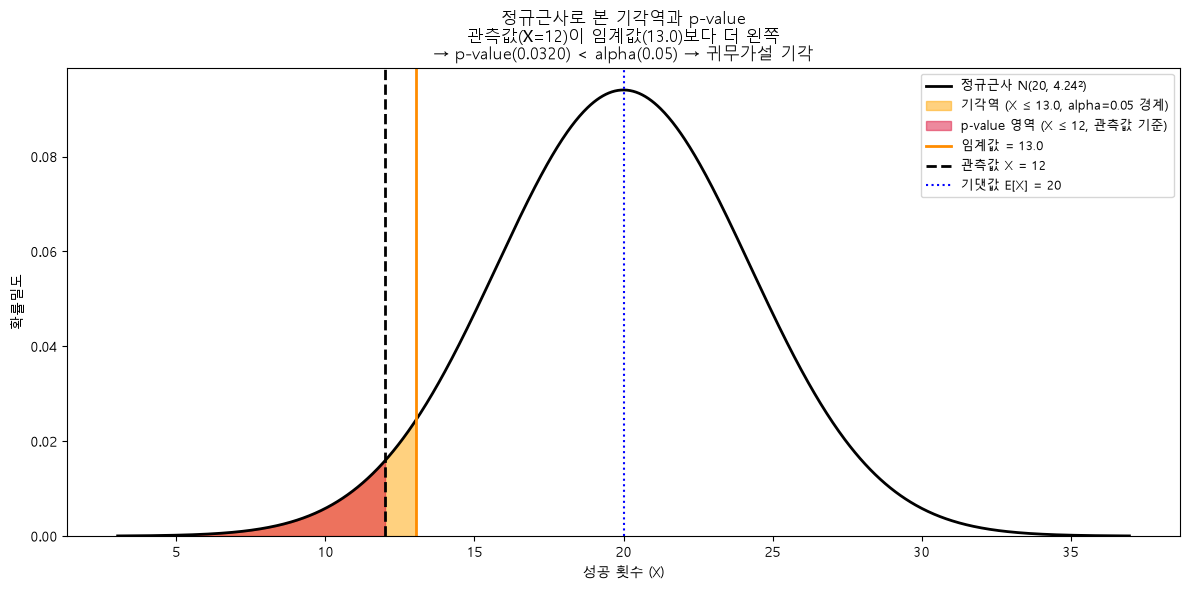

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binomtest

# 파라미터
n = 200
x = 12
p0 = 0.10
alpha = 0.05

# 이항분포 -> 정규분포 근사 (평균, 표준편차)
mu = n * p0
sigma = np.sqrt(n * p0 * (1 - p0))

# 실제 p-value는 이항검정으로 (참고용, 정확한 값)
result = binomtest(x, n, p0, alternative='less')
p_value = result.pvalue

# 정규근사 기준 임계값 (하위 5% 지점)
critical_value = mu + norm.ppf(alpha) * sigma

print(f"정규근사: 평균(mu)={mu:.2f}, 표준편차(sigma)={sigma:.2f}")
print(f"임계값(critical value, alpha=0.05 기준): {critical_value:.2f}")
print(f"관측값: {x}")
print(f"이항검정 p-value (정확값): {p_value:.4f}")

# x축 범위와 정규분포 곡선
x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y_values = norm.pdf(x_range, mu, sigma)

fig, ax = plt.subplots(figsize=(12, 6))

# 정규분포 곡선 (전체)
ax.plot(x_range, y_values, color='black', linewidth=2, label=f'정규근사 N({mu:.0f}, {sigma:.2f}²)')

# 기각역 (critical_value 이하): 주황색으로 색칠
reject_range = np.linspace(mu - 4*sigma, critical_value, 300)
ax.fill_between(reject_range, norm.pdf(reject_range, mu, sigma),
                 color='orange', alpha=0.5, label=f'기각역 (X ≤ {critical_value:.1f}, alpha=0.05 경계)')

# p-value 영역 (관측값 이하): 빨간색으로 색칠, 기각역 위에 겹쳐서
pval_range = np.linspace(mu - 4*sigma, x, 300)
ax.fill_between(pval_range, norm.pdf(pval_range, mu, sigma),
                 color='crimson', alpha=0.5, label=f'p-value 영역 (X ≤ {x}, 관측값 기준)')

# 세로선
ax.axvline(critical_value, color='darkorange', linestyle='-', linewidth=2,
           label=f'임계값 = {critical_value:.1f}')
ax.axvline(x, color='black', linestyle='--', linewidth=2,
           label=f'관측값 X = {x}')
ax.axvline(mu, color='blue', linestyle=':', linewidth=1.5,
           label=f'기댓값 E[X] = {mu:.0f}')

ax.set_xlabel('성공 횟수 (X)')
ax.set_ylabel('확률밀도')
ax.set_title(
    f'정규근사로 본 기각역과 p-value\n'
    f'관측값(X={x})이 임계값({critical_value:.1f})보다 더 왼쪽\n'
    f'→ p-value({p_value:.4f}) < alpha({alpha}) → 귀무가설 기각'
)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

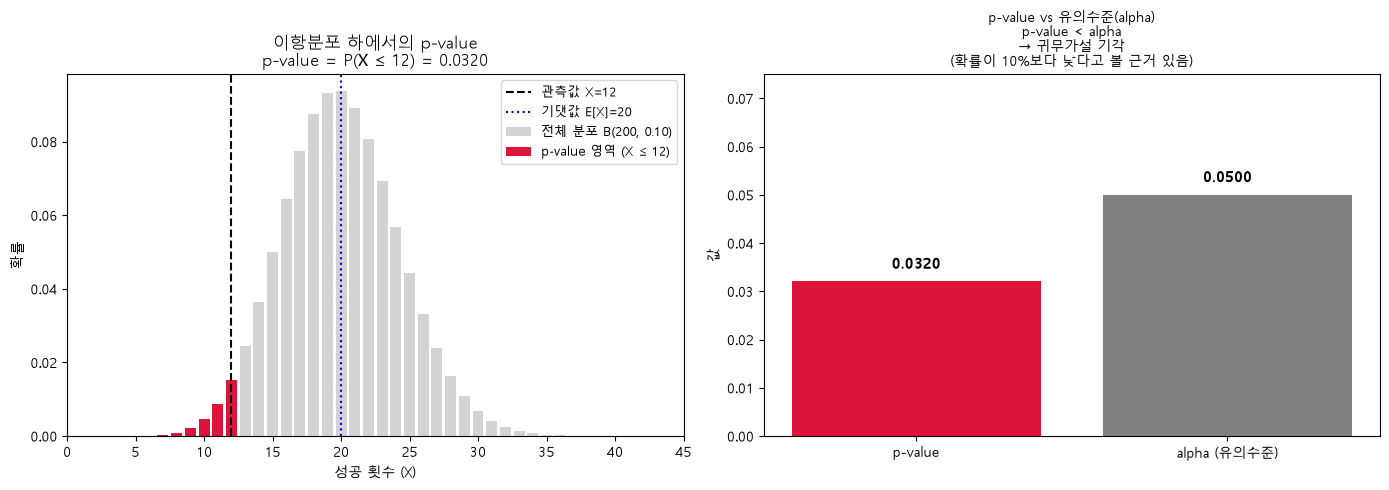

p-value: 0.0320
alpha: 0.05
결론: 귀무가설 기각


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, binomtest

# 파라미터
n = 200
x = 12
p0 = 0.10
alpha = 0.05

# 이항검정 결과
result = binomtest(x, n, p0, alternative='less')
p_value = result.pvalue

# 이항분포 전체 확률질량함수(PMF) 계산
k_values = np.arange(0, n + 1)
pmf_values = binom.pmf(k_values, n, p0)

# 그래프 그리기
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- ① 왼쪽: 이항분포 + p-value 영역 시각화 ---
ax1 = axes[0]

# 전체 분포는 회색으로
ax1.bar(k_values, pmf_values, color='lightgray', label='전체 분포 B(200, 0.10)')

# p-value에 해당하는 영역(x <= 12)은 빨간색으로 강조
mask = k_values <= x
ax1.bar(k_values[mask], pmf_values[mask], color='crimson', label=f'p-value 영역 (X ≤ {x})')

# 관측값 표시
ax1.axvline(x, color='black', linestyle='--', linewidth=1.5, label=f'관측값 X={x}')
# 기댓값(귀무가설 하의 평균) 표시
ax1.axvline(n * p0, color='blue', linestyle=':', linewidth=1.5, label=f'기댓값 E[X]={n*p0:.0f}')

ax1.set_xlim(0, 45)  # 의미 있는 구간만 확대해서 보기
ax1.set_xlabel('성공 횟수 (X)')
ax1.set_ylabel('확률')
ax1.set_title(f'이항분포 하에서의 p-value\np-value = P(X ≤ {x}) = {p_value:.4f}')
ax1.legend(fontsize=9)

# --- ② 오른쪽: p-value vs alpha 막대 비교 ---
ax2 = axes[1]

bars = ax2.bar(['p-value', 'alpha (유의수준)'], [p_value, alpha],
               color=['crimson' if p_value < alpha else 'steelblue', 'gray'])

# 막대 위에 값 표시
for bar, val in zip(bars, [p_value, alpha]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
              ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylim(0, max(p_value, alpha) * 1.5)
ax2.set_ylabel('값')

# 결론 텍스트 추가
if p_value < alpha:
    conclusion = "p-value < alpha\n→ 귀무가설 기각\n(확률이 10%보다 낮다고 볼 근거 있음)"
else:
    conclusion = "p-value ≥ alpha\n→ 귀무가설 기각 못함\n(10%보다 낮다고 단정 못함)"

ax2.set_title(f'p-value vs 유의수준(alpha)\n{conclusion}', fontsize=10)

plt.tight_layout()
plt.show()

print(f"p-value: {p_value:.4f}")
print(f"alpha: {alpha}")
print(f"결론: {'귀무가설 기각' if p_value < alpha else '귀무가설 기각 못함'}")

In [16]:
# [문제 1] Q4. H₀가 사실(실제 확률 = 10%)이라고 가정하고,
# 200번 뽑기를 10,000번 반복하는 시뮬레이션을 수행해봅시다.
# 힌트: numpy의 이항분포 랜덤 함수(np.random.binomial)를 사용해보세요.

# 여기에 코드를 작성해주세요.
import numpy as np

# 시뮬레이션 파라미터
n = 200          # 한 번의 실험에서 뽑기 횟수
p0 = 0.10        # H0가 사실이라고 가정한 실제 확률
n_simulations = 10000   # 반복 횟수

# 시드 고정 (결과 재현을 위해)
np.random.seed(42)

# H0(p=0.10)가 참이라는 가정 하에, "200번 뽑기"를 10,000번 반복 시뮬레이션
# 결과: 각 시뮬레이션마다 나온 성공 횟수가 담긴 배열 (길이 10,000)
simulated_successes = np.random.binomial(n=n, p=p0, size=n_simulations)

# 결과 확인
print(f"시뮬레이션 횟수: {n_simulations}")
print(f"각 시뮬레이션의 평균 성공 횟수: {simulated_successes.mean():.2f}  (이론적 기댓값: {n*p0:.1f})")
print(f"성공 횟수의 표준편차: {simulated_successes.std():.2f}")
print(f"시뮬레이션 결과 중 처음 20개: {simulated_successes[:20]}")

시뮬레이션 횟수: 10000
각 시뮬레이션의 평균 성공 횟수: 19.91  (이론적 기댓값: 20.0)
성공 횟수의 표준편차: 4.21
시뮬레이션 결과 중 처음 20개: [19 27 23 21 16 16 14 25 21 22 12 28 24 17 16 16 18 20 19 18]


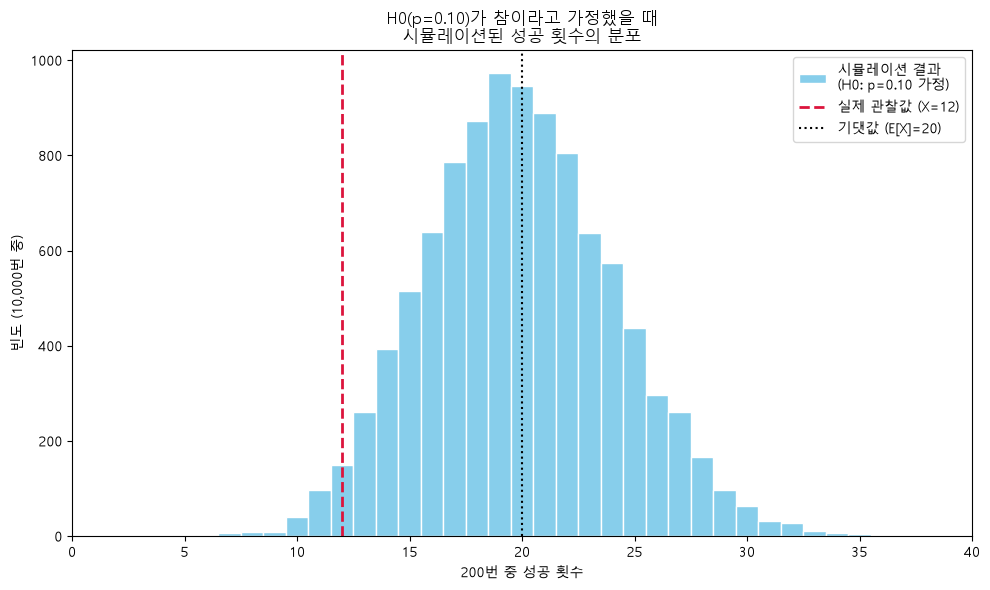

시뮬레이션 기반 p-value (X ≤ 12인 비율): 0.0313


In [17]:
# [문제 1] Q5. 시뮬레이션 결과를 히스토그램으로 그려봅시다.
# 실제 관찰값(12번 성공)을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.   
import numpy as np
import matplotlib.pyplot as plt

# (이전 Q4에서 만든 simulated_successes 배열을 그대로 사용)
n = 200
p0 = 0.10
n_simulations = 10000
x = 12  # 실제 관찰값

np.random.seed(42)
simulated_successes = np.random.binomial(n=n, p=p0, size=n_simulations)

# 히스토그램 그리기
plt.figure(figsize=(10, 6))

plt.hist(simulated_successes, bins=range(0, 41), color='skyblue',
         edgecolor='white', align='left', label='시뮬레이션 결과\n(H0: p=0.10 가정)')

# 실제 관찰값(12번)을 세로선으로 표시
plt.axvline(x, color='crimson', linestyle='--', linewidth=2,
            label=f'실제 관찰값 (X={x})')

# 기댓값도 참고용으로 같이 표시
plt.axvline(n * p0, color='black', linestyle=':', linewidth=1.5,
            label=f'기댓값 (E[X]={n*p0:.0f})')

plt.xlabel('200번 중 성공 횟수')
plt.ylabel('빈도 (10,000번 중)')
plt.title('H0(p=0.10)가 참이라고 가정했을 때\n시뮬레이션된 성공 횟수의 분포')
plt.legend()
plt.xlim(0, 40)

plt.tight_layout()
plt.show()

# 참고: 시뮬레이션에서 12 이하로 나온 비율 (다음 문제에서 쓰일 값)
sim_p_value = np.mean(simulated_successes <= x)
print(f"시뮬레이션 기반 p-value (X ≤ {x}인 비율): {sim_p_value:.4f}")

**🧠 데이터를 어떻게 읽을까요?**

- Q2에서 구한 p-값은 시뮬레이션 그래프의 어느 부분에 해당하며, 무엇을 의미하나요?

- 시뮬레이션 그래프를 볼 때, 우리가 관찰한 '12회 성공'은 개발사의 주장이 맞다는 가정 하에 흔한 일인가요, 드문 일인가요?

- 이 시뮬레이션 경험을 통해 "p-값이 작으면 귀무가설을 기각한다"는 규칙을 친구에게 어떻게 더 쉽게 설명할 수 있을까요?

- 만약 200번이 아니라 1,000번을 뽑아 같은 성공률(6%)이 나왔다면, p-값은 어떻게 달라질까요?

In [9]:
# [문제 1] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

# 문제 2. 과자 한 봉지의 중량은 150g이 맞을까? (난이도: 하)

**📘 문제**

- 한 식품 공장에서 생산하는 과자 한 봉지의 **목표 중량은 150g**입니다.

- 품질관리팀은 생산 공정이 목표 중량을 잘 맞추고 있는지 확인하기 위해,
  생산된 과자 **30봉지를 무작위로 추출**하여 무게를 측정했습니다.

- 이번 실습에서는 **일표본 t-검정(One-sample t-Test)**으로 표본 평균이 목표 중량과 유의미하게 다른지 검증하고,
  **"평균이 정확히 150g이라면"** 어떤 표본 평균들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

In [ ]:
# 데이터 생성 (과자 30봉지의 무게 측정값)
np.random.seed(42)
sample_weights = np.random.normal(loc=151.5, scale=2, size=30)
pop_mean = 150  # 목표 중량 (모평균)

# 표본 분포 시각화
sns.histplot(sample_weights, bins=10, kde=True)
plt.axvline(x=pop_mean, color='gray', linestyle='--', label='목표 중량 150g')
plt.title("추출한 과자 30봉지의 무게 분포")
plt.xlabel("무게 (g)")
plt.legend()
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 일표본 t-검정을 수행하여 t-통계량과 p-값을 구하고, 유의수준 0.05를 기준으로 결론을 내려봅시다.

- **"평균 무게가 정확히 150g이라면"** 30개짜리 표본의 평균이 어떻게 분포하는지 10,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 표본 평균이 그 분포에서 어디에 위치하는지 관찰해 봅시다.

In [ ]:
# [문제 2] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설):
# H₁ (대립가설):

In [ ]:
# [문제 2] Q2. 일표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 2] Q3. 유의수준 0.05를 기준으로 통계적 결론을 내리는 코드를 작성해봅시다.
# alpha = 0.05

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 2] Q4. H₀가 사실(평균 = 150g)이라고 가정하고, 30개짜리 표본을 10,000번 뽑아
# 각 표본의 평균을 리스트에 저장해봅시다.
# 힌트: 표준편차는 우리가 가진 표본의 표준편차를 사용한다고 가정하고, for 반복문을 사용해보세요.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 2] Q5. 시뮬레이션으로 얻은 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 표본 평균을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- Q5의 히스토그램은 무엇을 나타내나요? 이 분포의 모양이 정규분포와 비슷한 이유는 무엇일까요? (힌트: 4장에서 배운 중심극한정리)

- 우리가 실제로 관찰한 표본 평균(세로선)은 이 분포에서 흔하게 나타나는 값인가요? Q2의 p-값과 이 시각적 위치는 어떻게 관련되나요?

- 만약 p-값이 0.001이었다면, 세로선은 그래프의 어디쯤에 위치할 것으로 예상되나요?

- 이 결과는 공장 입장에서 어떤 조치를 취해야 함을 시사할까요? (목표보다 무겁게 나오는 것은 어떤 손실일까요?)

In [ ]:
# [문제 2] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

# 문제 3. 어떤 온라인 학습 방식이 더 효과적일까? (난이도: 중)

**📘 문제**

- 한 교육 기업에서 두 가지 다른 온라인 학습 방식(A, B)을 개발했습니다.

- 방식 A가 방식 B보다 학생들의 성적 향상에 더 효과적인지 알아보기 위해,
  두 그룹의 학생들에게 각각 다른 방식으로 한 달간 학습시킨 후 시험을 보게 했습니다.

- 이번 실습에서는 **이표본 t-검정(Two-sample t-Test)**으로 두 방식의 평균 점수 차이를 검증합니다.
  단, t-검정의 기본 가정인 **정규성**과 **등분산성**을 먼저 확인해야 합니다.

- 또한 **"두 방식의 효과가 완전히 똑같다면"** 우연히 나타날 수 있는 점수 차이의 범위를 시뮬레이션으로 확인해 봅니다.

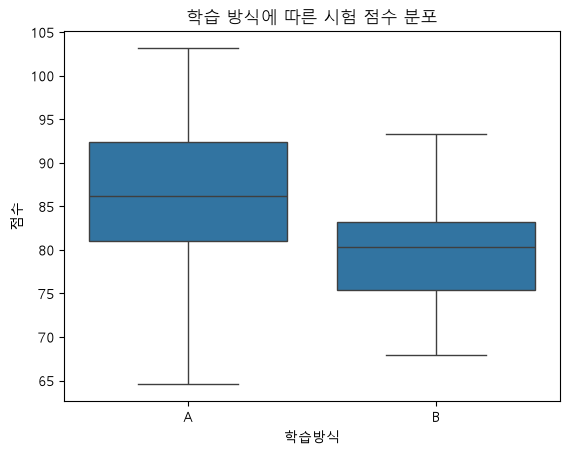

In [37]:
# 데이터 생성 (두 학습 방식의 시험 점수)
np.random.seed(0)
group_a_scores = np.random.normal(loc=85, scale=8, size=50)
group_b_scores = np.random.normal(loc=80, scale=7, size=50)

df_scores = pd.DataFrame({'점수': np.concatenate([group_a_scores, group_b_scores]),
                          '학습방식': ['A']*50 + ['B']*50})

# 두 그룹의 점수 분포 시각화
sns.boxplot(x='학습방식', y='점수', data=df_scores)
plt.title("학습 방식에 따른 시험 점수 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 두 그룹에 대해 **정규성 검정(Shapiro-Wilk test)**을 수행해 봅시다. (H₀: 데이터는 정규분포를 따른다.)

- **등분산성 검정(Levene's test)**을 수행해 봅시다. (H₀: 두 그룹의 분산은 같다.)

- 가정 검토 결과에 따라 `equal_var` 인수를 설정하여 **이표본 t-검정**을 수행해 봅시다.

- 두 그룹 데이터를 모두 합친 뒤 무작위로 다시 나누는 방식으로, **"두 방식의 효과가 같을 때"**의 평균 차이 분포를 시뮬레이션해 봅시다.

In [38]:
# [문제 3] Q1. 두 그룹에 대해 각각 정규성 검정(Shapiro-Wilk test)을 수행하고 p-값을 출력해봅시다.
# H₀: 데이터는 정규분포를 따른다.

# 여기에 코드를 작성해주세요.
from scipy import stats


stat_a, p_a = stats.shapiro(group_a_scores)
stat_b, p_b = stats.shapiro(group_b_scores)

print(f"[A 그룹] Shapiro-Wilk 통계량: {stat_a:.4f}, p-value: {p_a:.4f}")
print(f"[B 그룹] Shapiro-Wilk 통계량: {stat_b:.4f}, p-value: {p_b:.4f}")

alpha = 0.05
for name, p in [('A', p_a), ('B', p_b)]:
    if p > alpha:
        print(f"-> {name} 그룹: p-value({p:.4f}) > {alpha} -> 귀무가설 기각 실패 (정규분포를 따른다고 볼 수 있음)")
    else:
        print(f"-> {name} 그룹: p-value({p:.4f}) <= {alpha} -> 귀무가설 기각 (정규분포를 따른다고 보기 어려움)")

[A 그룹] Shapiro-Wilk 통계량: 0.9876, p-value: 0.8766
[B 그룹] Shapiro-Wilk 통계량: 0.9866, p-value: 0.8366
-> A 그룹: p-value(0.8766) > 0.05 -> 귀무가설 기각 실패 (정규분포를 따른다고 볼 수 있음)
-> B 그룹: p-value(0.8366) > 0.05 -> 귀무가설 기각 실패 (정규분포를 따른다고 볼 수 있음)


### 정규성 검정(Shapiro-Wilk test): "내가 가진 표본이 정규분포에서 나온 것처럼 보이는가?"를 수치화

정규성 검정의 W 통계량은 이 "점들이 대각선에 얼마나 잘 들어맞는지"를 하나의 숫자(상관계수와 비슷한 개념)로 압축
- W = 1에 가까울수록 → 정규분포와 거의 완벽히 일치
- W가 1보다 많이 작을수록 → 정규분포에서 벗어남  
  </br>
- 귀무가설 (H₀): 모집단은 정규분포를 따른다 (표본은 정규분포 모집단에서 뽑힌 것이다)
- 대립가설 (H₁): 모집단은 정규분포를 따르지 않는다

In [39]:
# [문제 3] Q2. 두 그룹에 대해 등분산성 검정(Levene's test)을 수행하고 p-값을 출력해봅시다.
# H₀: 두 그룹의 분산은 같다.

# 여기에 코드를 작성해주세요.

from scipy import stats

stat_levene, p_levene = stats.levene(group_a_scores, group_b_scores)

print(f"Levene 통계량: {stat_levene:.4f}, p-value: {p_levene:.4f}")

alpha = 0.05
if p_levene > alpha:
    print(f"-> p-value({p_levene:.4f}) > {alpha} -> 귀무가설 기각 실패 (두 그룹의 분산이 같다고 볼 수 있음)")
else:
    print(f"-> p-value({p_levene:.4f}) <= {alpha} -> 귀무가설 기각 (두 그룹의 분산이 다르다고 볼 수 있음)")

Levene 통계량: 6.1330, p-value: 0.0150
-> p-value(0.0150) <= 0.05 -> 귀무가설 기각 (두 그룹의 분산이 다르다고 볼 수 있음)


### 등분산성 검정(Levene's test): "두 그룹이 퍼진 정도(분산)가 서로 비슷한가?"를 수치화

등분산성 검정의 W 통계량은 이 "두 그룹이 퍼진 정도가 얼마나 비슷한지"를 하나의 숫자(상관계수와 비슷한 개념)로 압축
- W = 1에 가까움 → 그룹 간 차이가 그룹 내 잡음 수준과 비슷 → "차이 없다"에 가까움
- W이 1보다 훨씬 큼 → 그룹 간 차이가 잡음보다 확연히 큼 → "분산이 다르다"는 쪽에 힘이 실림  
  </br>  
- 귀무가설 (H₀): 두 그룹의 모분산은 같다 (σ²_A = σ²_B)
- 대립가설 (H₁): 두 그룹의 모분산은 다르다 (σ²_A ≠ σ²_B)

In [40]:
# [문제 3] Q3. 이표본 t-검정을 수행하여 t-통계량과 p-값을 구해봅시다.
# H₀: 두 그룹의 평균은 같다. / H₁: 두 그룹의 평균은 다르다.
# 등분산성 가정을 만족했는지 여부에 따라 equal_var 인수를 설정해보세요.

# 여기에 코드를 작성해주세요.

from scipy import stats


# 앞서 Levene's test에서 p-value = 0.0150 (< 0.05) → 등분산 가정 기각됨
# => 등분산을 가정하지 않는 Welch's t-test 사용 (equal_var=False)

t_stat, p_value = stats.ttest_ind(group_a_scores, group_b_scores, equal_var=False)

print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"-> p-value({p_value:.4f}) < {alpha} -> 귀무가설 기각 (두 그룹의 평균은 다르다)")
else:
    print(f"-> p-value({p_value:.4f}) >= {alpha} -> 귀무가설 기각 실패 (두 그룹의 평균이 다르다고 볼 근거 없음)")

t-통계량: 4.0426
p-value: 0.0001
-> p-value(0.0001) < 0.05 -> 귀무가설 기각 (두 그룹의 평균은 다르다)


### 이표본 t-검정(Two-sample t-test): "두 그룹의 평균이 같은가?"를 수치화

이표본 t-검정의 t-통계량은 이 "두 그룹이 퍼진 정도가 얼마나 비슷한지"를 하나의 숫자(상관계수와 비슷한 개념)로 압축
- t = 0에 가까움 → 그룹간 평균 차이가 우연한 흔들림 수준과 비슷 → "차이 없다"에 가까움
- |t|가 클수록 → 그룹간 평균 차이가 흔들림보다 확연히 큼 → "차이가 있다"는 쪽에 힘이 실림  
  </br>  
- 귀무가설 (H₀): 두 그룹의 평균은 같다 (μ_A = μ_B)
- 대립가설 (H₁): 두 그룹의 평균은 다르다 (μ_A ≠ μ_B)

In [41]:
# [문제 3] Q4. H₀가 사실(두 그룹의 평균이 같다)이라고 가정하고 시뮬레이션을 10,000번 수행해봅시다.
# 두 그룹의 데이터를 모두 합친 뒤(np.concatenate), 매 반복마다 비복원추출로 50개(가상 A그룹)와
# 나머지 50개(가상 B그룹)로 나누어 두 그룹의 평균 차이를 계산하고 리스트에 저장해보세요.
# 힌트: np.random.permutation 을 사용해보세요.

# 여기에 코드를 작성해주세요.

import numpy as np

all_scores = np.concatenate([group_a_scores, group_b_scores])
n_a = len(group_a_scores)  # 50

n_simulations = 10000
mean_diffs = []

for _ in range(n_simulations):
    shuffled = np.random.permutation(all_scores)   # 100개를 랜덤하게 섞음 (비복원추출)
    pseudo_a = shuffled[:n_a]                        # 앞 50개를 가상 A그룹으로
    pseudo_b = shuffled[n_a:]                         # 나머지 50개를 가상 B그룹으로
    diff = np.mean(pseudo_a) - np.mean(pseudo_b)
    mean_diffs.append(diff)

mean_diffs = np.array(mean_diffs)

print(f"시뮬레이션 횟수: {len(mean_diffs)}")
print(f"평균 차이들의 평균: {np.mean(mean_diffs):.4f}")
print(f"평균 차이들의 표준편차: {np.std(mean_diffs):.4f}")
print(f"평균 차이들의 최소/최대: {np.min(mean_diffs):.4f} / {np.max(mean_diffs):.4f}")

시뮬레이션 횟수: 10000
평균 차이들의 평균: -0.0183
평균 차이들의 표준편차: 1.6854
평균 차이들의 최소/최대: -6.1688 / 6.6107


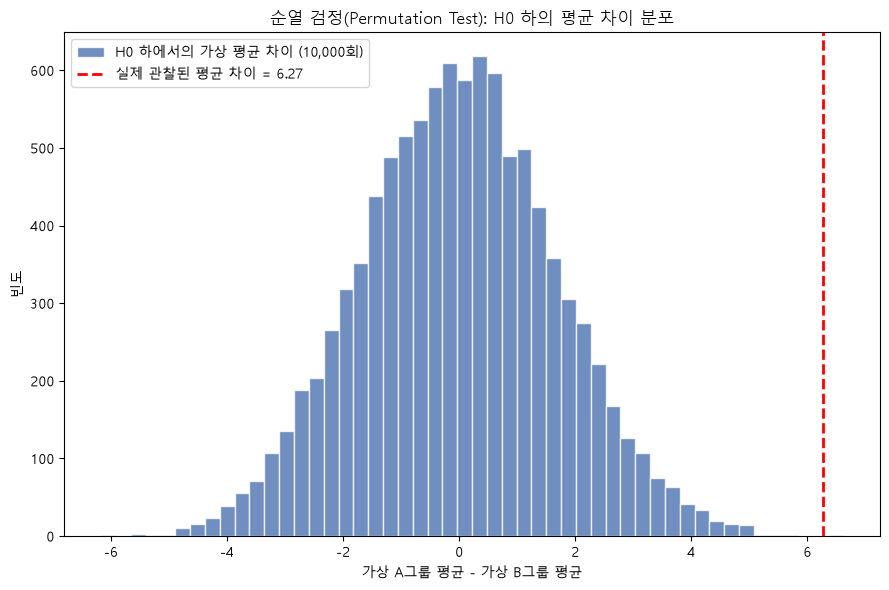

In [42]:
# [문제 3] Q5. 시뮬레이션으로 얻은 평균 차이의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 평균 차이(A그룹 평균 - B그룹 평균)를 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.

import matplotlib.pyplot as plt

observed_diff = np.mean(group_a_scores) - np.mean(group_b_scores)

plt.figure(figsize=(9, 6))
plt.hist(mean_diffs, bins=50, color='#4C72B0', edgecolor='white', alpha=0.8,
         label='H0 하에서의 가상 평균 차이 (10,000회)')

plt.axvline(observed_diff, color='red', linestyle='--', linewidth=2,
            label=f'실제 관찰된 평균 차이 = {observed_diff:.2f}')

plt.title("순열 검정(Permutation Test): H0 하의 평균 차이 분포")
plt.xlabel("가상 A그룹 평균 - 가상 B그룹 평균")
plt.ylabel("빈도")
plt.legend()
plt.tight_layout()
plt.show()

**🧠 데이터를 어떻게 읽을까요?**

- 정규성 검정과 등분산성 검정의 p-값은 각각 어떻게 해석해야 하나요? 이 결과는 이표본 t-검정을 사용하는 데 문제가 없음을 보여주나요?
    - 정규성 검정의 p-값
        - A 그룹: p = 0.8766
        - B 그룹: p = 0.8366  
        둘 다 유의수준인 0.05보다 커서 귀무가설(정규분포를 따른다) 을 기각하지 못함, 즉 "정규분포가 아니라고 볼 근거가 없다" --> **사실상 두 그룹 다 정규성을 만족한다**
    - 등분산성 검정의 p-값
        - p = 0.0150  
        유의수준인 0.05보다 작아서 귀무가설(두 그룹의 분산은 갖다) 을 기각, 즉 "두 그룹의 분산은 다르다"  --> **두 그룹간 등분산성은 만족하지 않는다**
    - 두 그룹이 **정규성을 만족**, **등분산성은 불만족** 이므로, 이표본 t-검정 중 Welch's t-test 사용 가능(equal_var=False)    
    <br/>
- Q5의 히스토그램 중심이 0에 가까운 이유는 무엇일까요?
    - Q5의 히스토그램은 무작위로 추출된 A그룹(50건)과 B그룹(50건)의 평균의 차이, 따라서 계속 작업을 수행(10000회)할때마다 중심극한정리에의해 두 그룹의 평균의 분포는 정규분포에 가까워짐,   
    따라서 차이는 0에 가까움  
    <br/>
- 실제 관찰된 평균 차이(세로선)는 "두 방식의 효과가 같다"고 가정했을 때 우연히 나타날 수 있는 범위 안에 있나요, 벗어나나요?
    - 실제 관찰된 평균 차이(6.27)는 우연히 나라날 수 있는 범위를 벗어남  
      무작위로 만들어진 가상의 평균은 대부분 -5 ~ +5 사이에 몰려있음, 6.27이상의 평균 차이가 나타난 경우는 10000회 중 1회로 한정  
    <br/>
- 이 시각적 판단과 Q3의 p-값은 어떤 관계가 있나요?
    - 두 경우의 p-값은 0.0001로 거의 동일함,   
    Q3의 t-검정을 통한 p-값은 이론적 가정과 공식 계산을 통해 나온 값, 시뮬레이션과 히스토그램을 통해 나온 p-값은 실험을 통해 확인한 값,   
    두가지 방법을 통해 거의 동일한 p-값을 도출해 내었으므로 원래 질문인 "두 학습 방식은 차이가 있는가"에 대해 차이가 있다는 결론에 더 무게가 실림   
    <br/>
- 통계적으로 유의미한 차이가 있다면, 교육 기업은 이 결과를 어떻게 활용할 수 있을까요?
    - 학생들의 수준에 따라 세그먼트를 나누어, 어느 공부방법이 더 적합한지 테스트하여 더 세부적인 공부방법 패키지 발굴
    - A 공부방법이 더 성적 향상을 시킨다는 점과 체계적인 성과분석 방식을 가지고 마케팅 자료로 활용, 브랜드화
    - A 공부방법이 왜 성적 향상을 시키는지 세부적으로 분석, 특히 방법론적으로 강사 역량 강화에 사용가능

# 문제 4. 연령대별로 선호하는 영화 장르가 다를까? (난이도: 중)

**📘 문제**

- 한 영화관에서 고객의 **연령대(20대, 30대, 40대)**에 따라 선호하는 **영화 장르(액션, 로맨스)**에 차이가 있는지 궁금해졌습니다.

- 이를 알아보기 위해 300명의 고객을 대상으로 설문조사를 진행하여 분할표를 얻었습니다.

- 이번 실습에서는 **카이제곱 독립성 검정(Chi-squared Test of Independence)**으로
  두 범주형 변수 사이에 연관성이 있는지 검증합니다.

- 또한 **"두 변수가 서로 아무 관련이 없다면(독립이라면)"** 어떤 카이제곱 통계량들이 나올 수 있는지 시뮬레이션으로 확인해 봅니다.

In [ ]:
# 데이터 생성 (관측 빈도 분할표)
data = {'액션': [70, 50, 30],
        '로맨스': [30, 60, 60]}
observed = pd.DataFrame(data, index=['20대', '30대', '40대'])

print("관측 빈도 (Observed Frequencies):")
print(observed)

# 분할표 시각화
observed.plot(kind='bar', figsize=(8, 5))
plt.title("연령대별 선호 장르 응답 수")
plt.xlabel("연령대")
plt.ylabel("응답 수 (명)")
plt.xticks(rotation=0)
plt.show()

**📌 아래를 수행해 보세요:**

- 귀무가설(H₀)과 대립가설(H₁)을 세워 봅시다.

- 카이제곱 독립성 검정을 수행하여 카이제곱 통계량, p-값, 자유도, **기대 빈도**를 구해봅시다.

- **"연령대와 선호 장르가 독립이라면"** 어떤 분할표들이 나타날 수 있는지 5,000번 시뮬레이션해 봅시다.

- 시뮬레이션으로 얻은 카이제곱 통계량 분포와 실제 관찰된 카이제곱 통계량을 비교해 봅시다.

In [ ]:
# [문제 4] Q1. 귀무가설(H₀)과 대립가설(H₁)을 주석으로 작성해봅시다.
# H₀ (귀무가설):
# H₁ (대립가설):

In [ ]:
# [문제 4] Q2. 카이제곱 독립성 검정을 수행하고 카이제곱 통계량, p-값, 자유도, 기대 빈도를 구해봅시다.
# 기대 빈도는 관측 빈도와 비교하기 쉽도록 데이터프레임 형태로 출력해보세요.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 4] Q3. H₀가 사실(두 변수가 독립)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 각 반복마다 300명의 가상 고객에게 연령대와 장르를 '독립적으로' 할당한 후,
# 가상 분할표를 만들고 카이제곱 통계량을 계산하여 리스트에 저장해보세요.
# 힌트 1: 전체 비율(observed.sum(axis=0) / 전체, observed.sum(axis=1) / 전체)을 확률로 사용
# 힌트 2: np.random.choice 로 300명의 연령대와 장르를 각각 독립적으로 생성
# 힌트 3: pd.crosstab 으로 분할표 생성 후 stats.chi2_contingency 로 통계량 계산

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 4] Q4. 시뮬레이션으로 얻은 카이제곱 통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 카이제곱 통계량을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- '기대 빈도'는 어떤 의미를 가지며, '관측 빈도'와의 차이가 클수록 카이제곱 통계량은 어떻게 변할까요?

- Q4의 히스토그램은 어떤 분포를 시각화한 것인가요? 실제 관찰된 카이제곱 통계량(세로선)은 흔한 값인가요, 극단적인 값인가요?

- 유의수준 0.05에서, 연령대와 선호 장르 사이에 통계적으로 유의미한 연관성이 있다고 결론 내릴 수 있나요? 그 이유는 무엇인가요?

- 이 결과를 바탕으로 영화관은 연령대별로 어떤 상영 전략이나 프로모션을 세울 수 있을까요?

In [ ]:
# [문제 4] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

# 문제 5. 미니 프로젝트 - 어떤 신규 비료가 가장 효과적일까? (난이도: 상)

**📘 문제**

- 한 농업 연구소에서 새로 개발한 비료 3종류(A, B, C)의 생산량 증대 효과를 비교하고자 합니다.

- 동일한 조건의 밭 30개를 준비하여, 각각 10개씩 비료 A, B, C를 투여한 후 수확량을 측정했습니다.

- 이번 실습에서는 **분산분석(ANOVA)**으로 세 비료 간 평균 수확량에 차이가 있는지 검증하고,
  차이가 있다면 **사후분석(Tukey's HSD)**으로 어떤 비료끼리 차이가 나는지 확인합니다.

- 마지막으로 **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량이 나올 수 있는지 시뮬레이션하고,
  분석 결과를 바탕으로 연구소에 어떤 비료를 추천할지까지 생각해 봅니다.

In [ ]:
# 데이터 생성 (비료 종류별 수확량)
np.random.seed(123)
fertilizer_a = np.random.normal(loc=105, scale=10, size=10)
fertilizer_b = np.random.normal(loc=120, scale=12, size=10)
fertilizer_c = np.random.normal(loc=108, scale=9, size=10)

# 데이터프레임으로 변환 (사후분석을 위해)
df = pd.DataFrame({'수확량': np.concatenate([fertilizer_a, fertilizer_b, fertilizer_c]),
                   '비료종류': ['A']*10 + ['B']*10 + ['C']*10})

# 데이터 탐색 시각화
sns.boxplot(x='비료종류', y='수확량', data=df)
plt.title("비료 종류에 따른 수확량 분포")
plt.show()

**📌 아래를 수행해 보세요:**

- 세 그룹에 대해 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.

- ANOVA 결과가 유의미할 경우에만 **Tukey's HSD 사후분석**을 수행하고 결과를 해석해 봅시다.

- **"세 비료의 효과가 완전히 똑같다면"** 어떤 F-통계량들이 나오는지 5,000번 시뮬레이션해 봅시다.

- 히스토그램을 그리고, 실제 관찰된 F-통계량이 얼마나 극단적인 값인지 확인해 봅시다.

- 분석 결과를 종합하여 연구소에 추천할 비료를 정해 봅시다.

In [ ]:
# [문제 5] Q1. 분산분석(ANOVA)을 수행하여 F-통계량과 p-값을 구해봅시다.
# H₀: 세 비료의 평균 수확량은 모두 같다.
# H₁: 적어도 하나 이상의 비료 평균 수확량은 다르다.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q2. ANOVA의 p-값이 유의수준 0.05보다 작을 경우에만
# Tukey's HSD 사후분석을 수행하고 결과를 출력해봅시다.
# 힌트: pairwise_tukeyhsd(endog=수확량, groups=비료종류, alpha=0.05)

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q3. H₀가 사실(세 그룹의 평균이 모두 같다)이라고 가정하고 시뮬레이션을 5,000번 수행해봅시다.
# 모든 데이터를 합친 평균과 표준편차를 가진 H₀ 모집단에서 10개씩 3개의 가상 그룹을 생성하고,
# 이 가상 그룹들로 ANOVA를 수행하여 F-통계량을 리스트에 저장해보세요.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q4. 시뮬레이션으로 얻은 F-통계량의 분포를 히스토그램으로 그려봅시다.
# 실제 관찰된 F-통계량을 세로선으로 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q5. 분석 결과를 바탕으로 연구소에 어떤 비료를 추천하시겠습니까?
# 여기에 의견을 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- ANOVA 검정의 p-값을 통해 어떤 결론을 내릴 수 있나요? 이 결과는 "세 비료가 모두 동일한 효과를 가진다"는 뜻인가요, "적어도 하나는 다르다"는 뜻인가요?

- Tukey's HSD 결과표의 `reject` 열에서 `True`로 표시된 조합은 무엇이며, 이는 무엇을 의미하나요?

- `meandiff` 열의 값은 어떤 정보를 주나요? 신뢰구간(`lower`, `upper`)이 0을 포함하는지 여부는 무엇을 뜻할까요?

- 그룹별 표본 크기가 10개로 작다는 점은 이 결론의 신뢰도에 어떤 영향을 줄까요? 어떻게 개선할 수 있을까요?

In [ ]:
# [문제 5] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.